<a href="https://colab.research.google.com/github/karenrosas0410-pixel/Estad-stica-2026B-/blob/main/Karen_Problemas_Un_Factor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Analiza los siguientes diseños experimentales, e intenta sacar el máximo valor a la información. Verifica los supuestos (linealidad, homscedasticidad e independencia), puedes apoyarte en [la guía de la unidad 4](https://github.com/DrFaus/Estadistica2026B/blob/main/DiseniosExperimentalesUnFactor.ipynb). Aplica una prueba post-hoc en caso que sea necesario. Redacta una conclusión y una recomendación para las personas que recolectaron los datos.

1. **Comparación de cuatro métodos de ensamble:** Un equipo de mejora investiga el efecto de cuatro métodos de ensamble A, B, C y D, sobre el tiempo de ensamble en minutos. En primera instancia, la estrategia experimental es aplicar cuatro veces los cuatro métodos de ensamble en orden completamente aleatorio (las 16 pruebas en orden aleatorio). Los tiempos de ensamble obtenidos se muestran en la tabla 3.1. Si se usa el diseño completamente al azar (DCA), se supone que, además del método de ensamble, no existe ningún otro factor que influya de manera significativa sobre la variable de respuesta (tiempo de ensamble).

| Método de ensamble | A  | B  | C  | D  |
|--------------------|----|----|----|----|
|                    | 6  | 7  | 11 | 10 |
|                    | 8  | 9  | 16 | 12 |
|                    | 7  | 10 | 11 | 11 |
|                    | 8  | 8  | 13 | 9  |


In [ ]:
#Diana Karen Rosas Ortega
# Lo primero que hay que se hace es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
metodo,tiempo
A,6
A,8
A,7
A,8
B,7
B,9
B,10
B,8
C,11
C,16
C,11
C,13
D,10
D,12
D,11
D,9
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.

,metodo,tiempo
0,A,6
1,A,8
2,A,7
3,A,8
4,B,7
5,B,9
6,B,10
7,B,8
8,C,11
9,C,16


In [ ]:
#Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos una media es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'tiempo ~ C(metodo)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(metodo),69.5,3.0,9.423729,0.001771
Residual,29.5,12.0,NaN,NaN


valor-p (Shapiro) = 0.2808008139238357


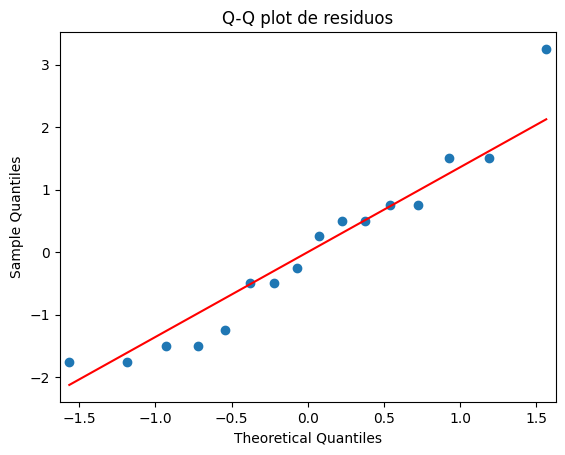

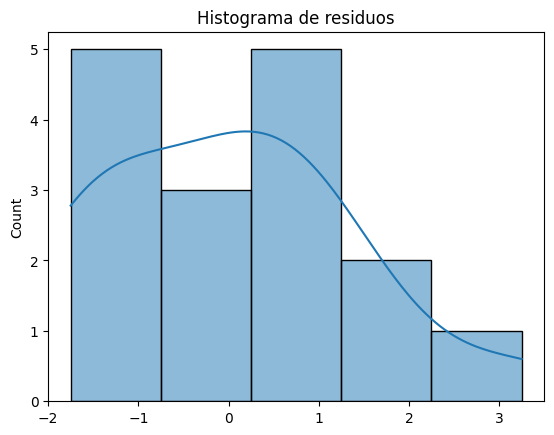

In [ ]:
#Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['metodo'] == 'A']['tiempo']
grupo2 = df[df['metodo'] == 'B']['tiempo']
grupo3 = df[df['metodo'] == 'C']['tiempo']
grupo4 = df[df['metodo'] == 'D']['tiempo']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.4485146502776487


In [ ]:
#Existe homocedasticidad por lo tanto se acepta Ho

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B     1.25 0.6805 -2.0416 4.5416  False
     A      C      5.5 0.0016  2.2084 8.7916   True
     A      D     3.25 0.0533 -0.0416 6.5416  False
     B      C     4.25  0.011  0.9584 7.5416   True
     B      D      2.0 0.3181 -1.2916 5.2916  False
     C      D    -2.25 0.2309 -5.5416 1.0416  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

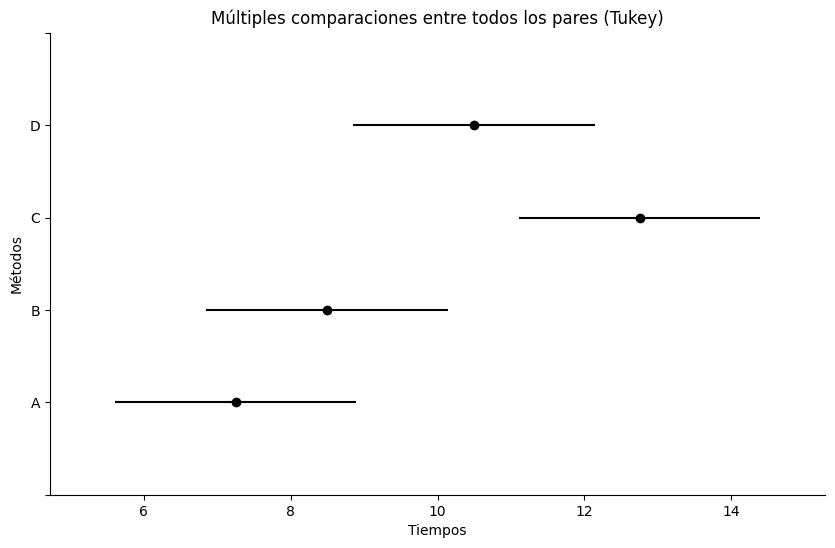

In [ ]:

#Diana Karen Rosas Ortega
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['tiempo'], groups=df['metodo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Métodos", xlabel="Tiempos")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
#Diana Karen Rosas Ortega
# se pueden recomendar los metodos A,B,D


2. **Comparación de cuatro tipos de cuero:** Un fabricante de calzado desea mejorar la calidad de las suelas, las cuales se pueden hacer con uno de los cuatro tipos de cuero A, B, C y D disponibles en el mercado. Para ello, prueba los cueros con una máquina que hace pasar los zapatos por una superficie abrasiva; la suela de éstos se desgasta al pasarla por dicha superficie. Como criterio de desgaste se usa la pérdida de peso después de un número fijo de ciclos. Se prueban en orden aleatorio 24 zapatos, seis de cada tipo de cuero. Al hacer las pruebas en orden completamente al azar se evitan sesgos y las mediciones en un tipo de cuero resultan independientes de las demás. Los datos (en miligramos) sobre el desgaste de cada tipo de cuero se muestran en la tabla.

| Tipo de cuero | Observaciones                  | Promedio |
|---------------|--------------------------------|----------|
| A             | 264, 260, 258, 241, 262, 255 | 256.7    |
| B             | 208, 220, 216, 200, 213, 206 | 209.8    |
| C             | 220, 263, 219, 225, 230, 228 | 230.8    |
| D             | 217, 226, 215, 227, 220, 222 | 220.7    |


In [1]:
# Diana Karen Rosas Ortega
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
tipos_cuero,desgaste
A,264
A,260
A,258
A,241
A,262
A,255
B,208
B,220
B,216
B,200
B,213
B,206
C,220
C,263
C,219
C,225
C,230
C,228
D,217
D,226
D,215
D,227
D,220
D,222
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,tipos_cuero,desgaste
0,A,264
1,A,260
2,A,258
3,A,241
4,A,262
5,A,255
6,B,208
7,B,220
8,B,216
9,B,200


In [2]:
 # Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'desgaste ~ C(tipos_cuero)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(tipos_cuero),7019.458333,3.0,22.755356,0.000001
Residual,2056.500000,20.0,NaN,NaN


In [ ]:
# Se puede observar que almenos una media es distinta por lo tanto aceptamos Ho

valor-p (Shapiro) = 0.00967014513830024


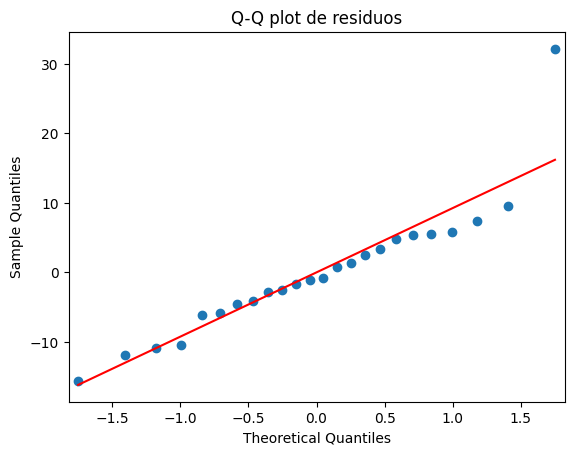

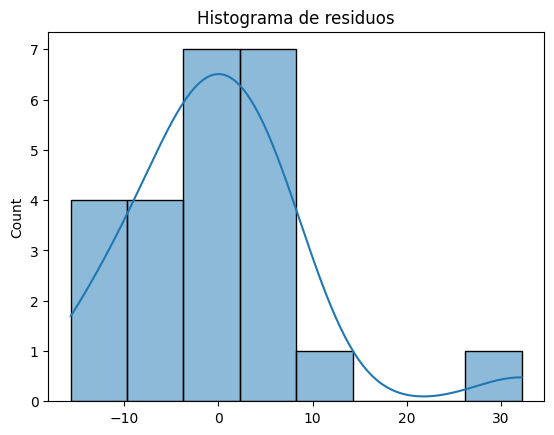

In [3]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [4]:
# Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['tipos_cuero'] == 'A']['desgaste']
grupo2 = df[df['tipos_cuero'] == 'B']['desgaste']
grupo3 = df[df['tipos_cuero'] == 'C']['desgaste']
grupo4 = df[df['tipos_cuero'] == 'D']['desgaste']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.6351342635286297


In [ ]:
# Si existe homosedasticidad ya que el valor p es mayor al nivel de significancia

Lambda óptimo: -3.707788382033557


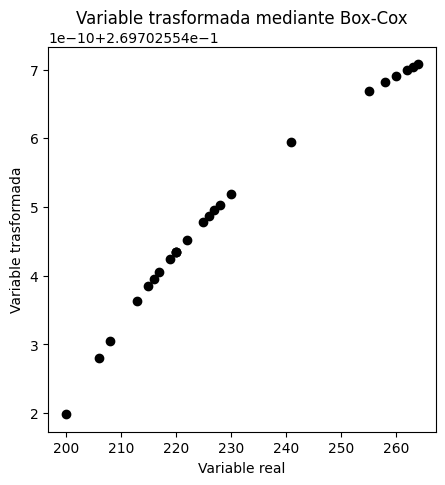

In [5]:
# Diana Karen Rosas Ortega
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["desgaste_boxcox"], lambda_opt = boxcox(df["desgaste"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["desgaste"], df["desgaste_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [6]:
# Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'desgaste_boxcox~ C(tipos_cuero)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(tipos_cuero),3.735519e-19,3.0,23.368221,9.595697e-07
Residual,1.065698e-19,20.0,NaN,NaN


valor-p (Shapiro) = 0.4576953738713335


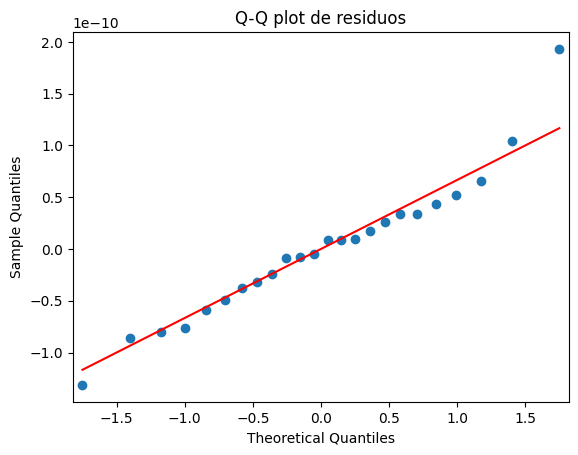

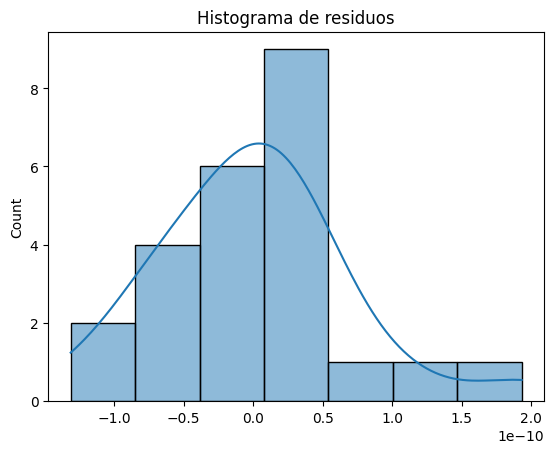

In [7]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# DE acuerdo a la propuesta de shapiro ya existe normalidad

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower upper reject
------------------------------------------------
     A      B     -0.0    0.0  -0.0  -0.0   True
     A      C     -0.0 0.0048  -0.0  -0.0   True
     A      D     -0.0 0.0001  -0.0  -0.0   True
     B      C      0.0 0.0018   0.0   0.0   True
     B      D      0.0 0.0613  -0.0   0.0  False
     C      D     -0.0  0.401  -0.0   0.0  False
------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

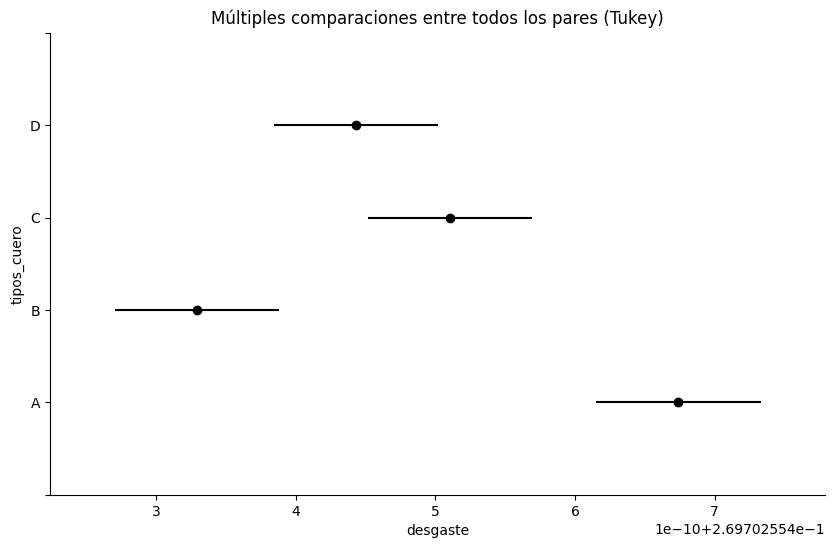

In [8]:
# Diana Karen Rosas Ortega
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['desgaste_boxcox'], groups=df['tipos_cuero'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="tipos_cuero", xlabel="desgaste")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

3. En un centro de investigación se realiza un estudio para comparar varios tratamientos que, al aplicarse previamente a los frijoles crudos, reducen su tiempo de cocción. Estos tratamientos son a base de bicarbonato de sodio y cloruro de sodio o sal común. El primer tratamiento ($T_1$) es el de control, que consiste en no aplicar ningún tratamiento. El tratamiento $T_2$ es el remojo en agua con bicarbonato de sodio, el $T_3$ es remojar en agua con sal común y el $T_4$ es remojar en agua con una combinación de ambos ingredientes en proporciones iguales. La variable de respuesta es el tiempo de cocción en minutos. Los datos se muestran en la siguiente tabla:

| $T_1$ | $T_2$  | $T_3$  | $T_4$  |
|---------|-----|-----|-----|
| 213     | 76  | 57  | 84  |
| 214     | 85  | 67  | 82  |
| 204     | 74  | 55  | 85  |
| 208     | 78  | 64  | 92  |
| 212     | 82  | 61  | 87  |
| 200     | 75  | 63  | 79  |
| 207     | 82  | 63  | 90  |



In [9]:
# Diana Karen Rosas Ortega
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
tratamiento,tiempo
T1,213
T1,214
T1,204
T1,208
T1,212
T1,200
T1,207
T2,76
T2,85
T2,74
T2,78
T2,82
T2,75
T2,82
T3,57
T3,67
T3,55
T3,64
T3,61
T3,63
T3,63
T4,84
T4,82
T4,85
T4,92
T4,87
T4,79
T4,90
'''
df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,tratamiento,tiempo
0,T1,213
1,T1,214
2,T1,204
3,T1,208
4,T1,212
5,T1,200
6,T1,207
7,T2,76
8,T2,85
9,T2,74


In [10]:
# Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'tiempo ~ C(tratamiento)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(tratamiento),95041.250000,3.0,1558.966022,1.260640e-27
Residual,487.714286,24.0,NaN,NaN


In [ ]:
# se acepta Ho ya que al menos una media es distinta

valor-p (Shapiro) = 0.34689165649616827


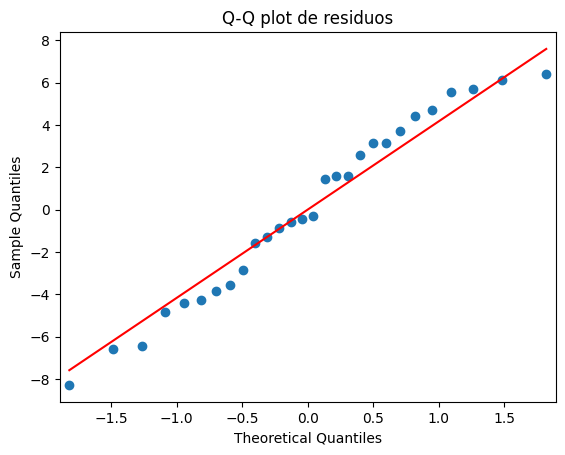

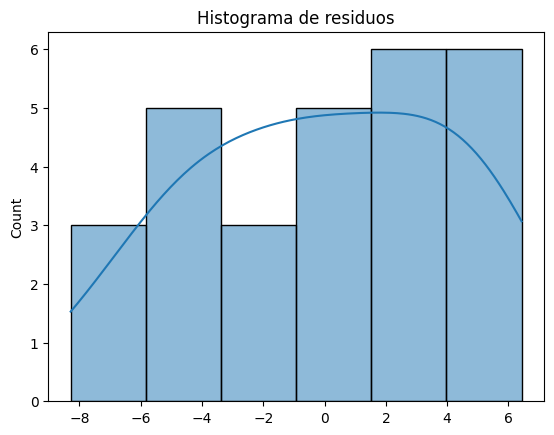

In [11]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [12]:
# Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['tratamiento'] == 'T1']['tiempo']
grupo2 = df[df['tratamiento'] == 'T2']['tiempo']
grupo3 = df[df['tratamiento'] == 'T3']['tiempo']
grupo4 = df[df['tratamiento'] == 'T4']['tiempo']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.9201477397132211


In [ ]:
# Existe homocedastisidad ya que el valor p es mayor que al de significancia

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
    T1     T2 -129.4286    0.0 -136.0757 -122.7815   True
    T1     T3 -146.8571    0.0 -153.5043   -140.21   True
    T1     T4 -122.7143    0.0 -129.3614 -116.0672   True
    T2     T3  -17.4286    0.0  -24.0757  -10.7815   True
    T2     T4    6.7143 0.0471    0.0672   13.3614   True
    T3     T4   24.1429    0.0   17.4957     30.79   True
---------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

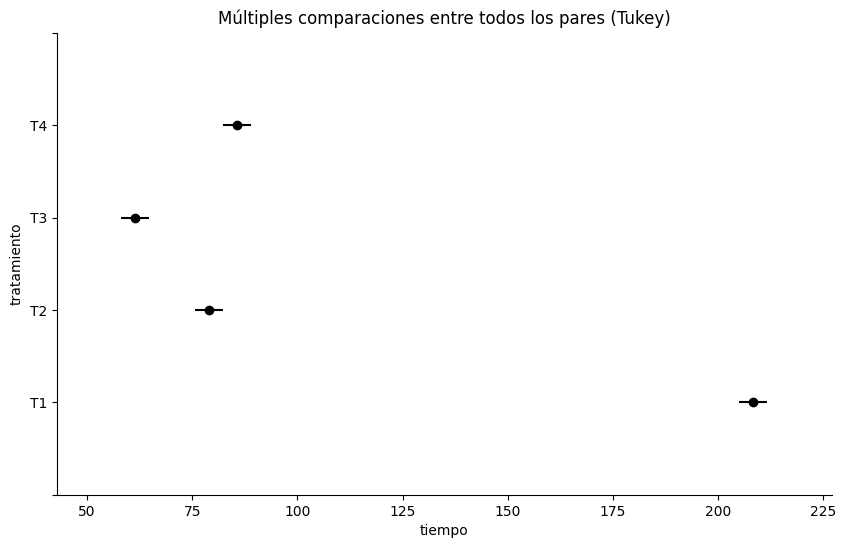

In [13]:
# Diana Karen Rosas Ortega
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['tiempo'], groups=df['tratamiento'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="tratamiento", xlabel="tiempo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# dejar los frijoles en agua y sal se cuecen mas rapido

4. Para estudiar la confiabilidad de ciertos tableros electrónicos para carros, se someten a un envejecimiento acelerado durante 100 horas a determinada temperatura, y como variable de interés se mide la intensidad de corriente que circula entre dos puntos, cuyos valores aumentan con el deterioro. Se probaron 20 módulos repartidos de manera equitativa en cinco temperaturas y los resultados obtenidos fueron los siguientes:

| 20°C | 40°C | 60°C | 80°C | 100°C |
|------|------|------|------|-------|
| 15   | 17   | 23   | 28   | 45    |
| 18   | 21   | 19   | 32   | 51    |
| 13   | 11   | 25   | 34   | 57    |
| 12   | 16   | 22   | 31   | 48    |


In [14]:
# Diana Karen Rosas Ortega
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
temperatura,deterioro
20°C,15
20°C,18
20°C,13
20°C,12
40°C,17
40°C,21
40°C,11
40°C,16
60°C,23
60°C,19
60°C,25
60°C,22
80°C,28
80°C,32
80°C,34
80°C,31
100°C,45
100°C,51
100°C,57
100°C,48
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,temperatura,deterioro
0,20°C,15
1,20°C,18
2,20°C,13
3,20°C,12
4,40°C,17
5,40°C,21
6,40°C,11
7,40°C,16
8,60°C,23
9,60°C,19


In [15]:
 # Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'deterioro ~ C(temperatura)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(temperatura),3411.8,4.0,68.054521,1.963480e-09
Residual,188.0,15.0,NaN,NaN


In [16]:
# Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['temperatura'] == '20°C']['deterioro']
grupo2 = df[df['temperatura'] == '40°C']['deterioro']
grupo3 = df[df['temperatura'] == '60°C']['deterioro']
grupo4 = df[df['temperatura'] == '80°C']['deterioro']
grupo5 = df[df['temperatura'] == '100°C']['deterioro']
stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.847865119796738


In [ ]:
# Existe homosedasticidad ya que el valor p es mayor que al de significancia

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
 100°C   20°C   -35.75    0.0 -43.4801 -28.0199   True
 100°C   40°C    -34.0    0.0 -41.7301 -26.2699   True
 100°C   60°C    -28.0    0.0 -35.7301 -20.2699   True
 100°C   80°C    -19.0    0.0 -26.7301 -11.2699   True
  20°C   40°C     1.75 0.9535  -5.9801   9.4801  False
  20°C   60°C     7.75 0.0493   0.0199  15.4801   True
  20°C   80°C    16.75 0.0001   9.0199  24.4801   True
  40°C   60°C      6.0 0.1696  -1.7301  13.7301  False
  40°C   80°C     15.0 0.0002   7.2699  22.7301   True
  60°C   80°C      9.0 0.0191   1.2699  16.7301   True
------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

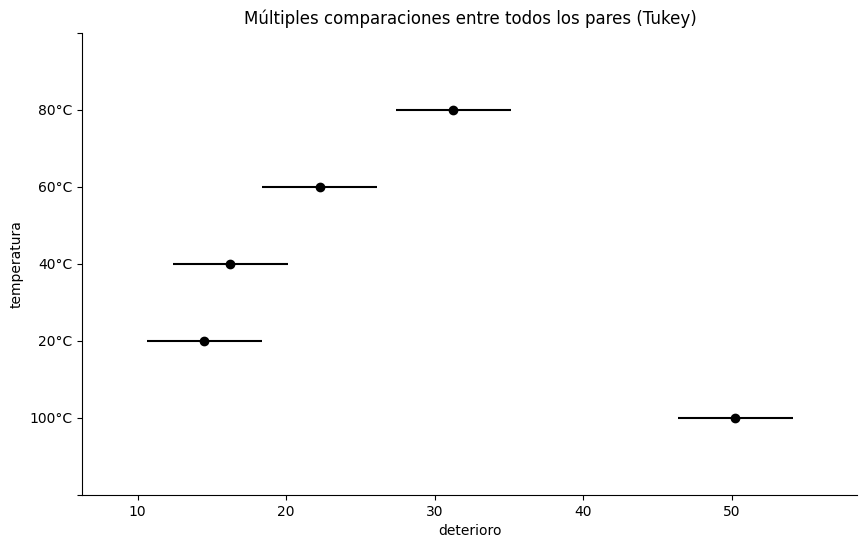

In [17]:
# Diana Karen Rosas Ortega
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['deterioro'], groups=df['temperatura'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="temperatura", xlabel="deterioro")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

5. En una empresa de manufactura se propone un tratamiento para reducir el porcentaje de productos defectuosos. Para validar esta propuesta se diseñó un experimento en el que se producía con o sin la propuesta de mejora. Cada corrida experimental consistió en producir un lote y la variable de respuesta es el porcentaje de producto defectuoso. Se hicieron 25 réplicas para cada tratamiento. Los datos obtenidos se muestran a continuación:

| Tratamiento     | Porcentaje de producto defectuoso                                     |
|-----------------|----------------------------------------------------------------------|
| Con tratam.     | 5.3, 4.0, 4.0, 4.0, 2.6, 2.1, 5.1, 4.1, 4.1, 3.2, 5.1, 2.2, 4.1     |
| Sin tratam.     | 8.0, 13.2, 7.2, 8.2, 9.1, 6.7, 12.6, 16.3, 9.2, 6.4, 7.2, 17.2, 12.3 |


In [18]:
# Diana Karen Rosas Ortega
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
tratamiento,porcentaje_defectuoso
Con tratamiento,5.3
Con tratamiento,4.0
Con tratamiento,4.0
Con tratamiento,4.0
Con tratamiento,2.6
Con tratamiento,2.1
Con tratamiento,5.1
Con tratamiento,4.1
Con tratamiento,4.1
Con tratamiento,3.2
Con tratamiento,5.1
Con tratamiento,2.2
Con tratamiento,4.1
Sin tratamiento,8.0
Sin tratamiento,13.2
Sin tratamiento,7.2
Sin tratamiento,8.2
Sin tratamiento,9.1
Sin tratamiento,6.7
Sin tratamiento,12.6
Sin tratamiento,16.3
Sin tratamiento,9.2
Sin tratamiento,6.4
Sin tratamiento,7.2
Sin tratamiento,17.2
Sin tratamiento,12.3
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df


,tratamiento,porcentaje_defectuoso
0,Con tratamiento,5.3
1,Con tratamiento,4.0
2,Con tratamiento,4.0
3,Con tratamiento,4.0
4,Con tratamiento,2.6
5,Con tratamiento,2.1
6,Con tratamiento,5.1
7,Con tratamiento,4.1
8,Con tratamiento,4.1
9,Con tratamiento,3.2


In [19]:
# Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'porcentaje_defectuoso ~ C(tratamiento)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(tratamiento),269.449615,1.0,37.102806,0.000003
Residual,174.293846,24.0,NaN,NaN


valor-p (Shapiro) = 0.08240142335256262


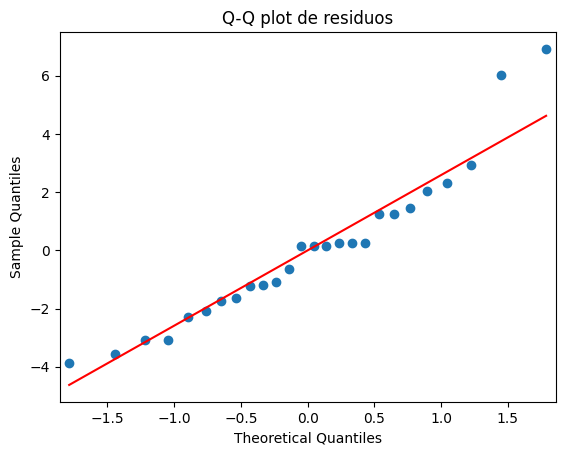

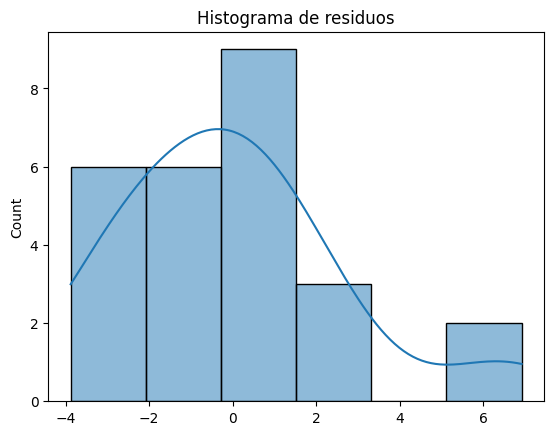

In [20]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# si hay normalidad

In [21]:
# Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['tratamiento'] == 'Con_tratamiento']['porcentaje_defectuoso']
grupo2 = df[df['tratamiento'] == 'Sin_tratamiento']['porcentaje_defectuoso']
stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: nan


/tmp/ipykernel_503/3322215756.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = levene(grupo1, grupo2, grupo3, grupo4)


In [ ]:
# Hay heterocedasticidad ya que el valor P es menor a nivel de significancia

Lambda óptimo: -0.05387226813423122


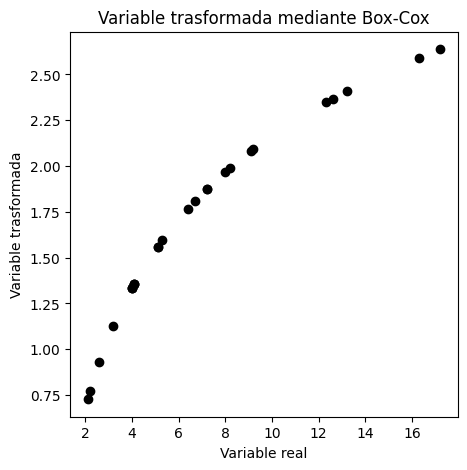

In [22]:
# Diana Karen Rosas Ortega
#Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["porcentaje_defectuoso_boxcox"], lambda_opt = boxcox(df["porcentaje_defectuoso"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["porcentaje_defectuoso"], df["porcentaje_defectuoso_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [23]:
# Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'porcentaje_defectuoso_boxcox ~ C(tratamiento)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(tratamiento),5.040324,1.0,58.843753,6.583032e-08
Residual,2.055745,24.0,NaN,NaN


valor-p (Shapiro) = 0.5855089546322916


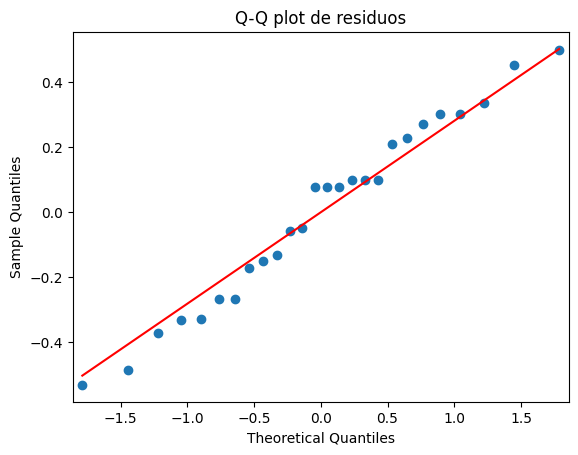

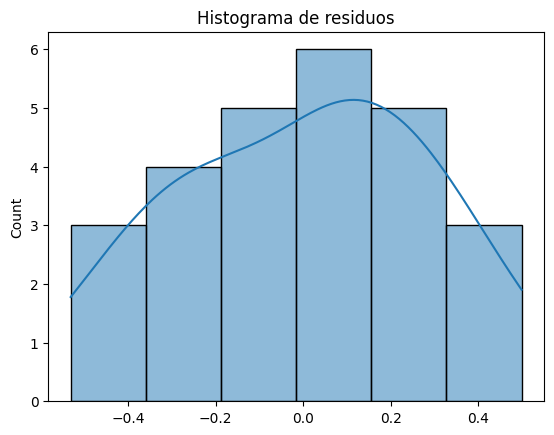

In [24]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# existe normalidad por lo tanto se acepta Ho

In [25]:
# Diana Karen Rosas Ortega
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['tratamiento'] == 'con_tratamiento']['porcentaje_defectuoso_boxcox']
grupo2 = df[df['tratamiento'] == 'sin_tratamiento']['porcentaje_defectuoso_boxcox']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: nan


/tmp/ipykernel_503/2515330218.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = levene(grupo1, grupo2, grupo3, grupo4)


In [ ]:
#Hay heterocedasticidad por lo tanto no se acepta H0

In [26]:
# Diana Karen Rosas Ortega
from scipy.stats import kruskal

# Separar las calificaciones por tratamiento
grupo1 = df[df['tratamiento'] == 'con_tratamiento']['porcentaje_defectuoso']
grupo2 = df[df['tratamiento'] == 'sin_tratamiento']['porcentaje_defectuoso']

# Prueba de Kruskal-Wallis
estadistico, valor_p = kruskal(grupo1, grupo2)

print(f"Estadístico de Kruskal-Wallis: {estadistico:.4f}")
print(f"Valor-p: {valor_p:.4f}")

Estadístico de Kruskal-Wallis: nan
Valor-p: nan


/tmp/ipykernel_503/1265602087.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  estadistico, valor_p = kruskal(grupo1, grupo2)


6. Una compañía farmacéutica desea evaluar el efecto que tiene la cantidad de almidón en la dureza de las tabletas. Se decidió producir lotes con una cantidad determinada de almidón, y que las cantidades de almidón a aprobar fueran 2%, 5% y 10%. La variable de respuesta sería el promedio de la dureza de 20 tabletas de cada lote. Se hicieron 4 réplicas por tratamiento y se obtuvieron los siguientes resultados:

| % de almidón | Dureza               |
|--------------|----------------------|
| 2            | 4.3, 5.2, 4.8, 4.5  |
| 5            | 6.5, 7.3, 6.9, 6.1  |
| 10           | 9.0, 7.8, 8.5, 8.1  |


In [27]:
# Diana Karen Rosas Ortega
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
almidon,promedio_dureza
2,4.3
2,5.2
2,4.8
2,4.5
5,6.5
5,7.3
5,6.9
5,6.1
10,9.0
10,7.8
10,8.5
10,8.1
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,almidon,promedio_dureza
0,2,4.3
1,2,5.2
2,2,4.8
3,2,4.5
4,5,6.5
5,5,7.3
6,5,6.9
7,5,6.1
8,10,9.0
9,10,7.8


In [29]:
# Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'promedio_dureza ~ C(almidon)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(almidon),26.726667,2.0,58.101449,0.000007
Residual,2.070000,9.0,NaN,NaN


valor-p (Shapiro) = 0.42952068080371164


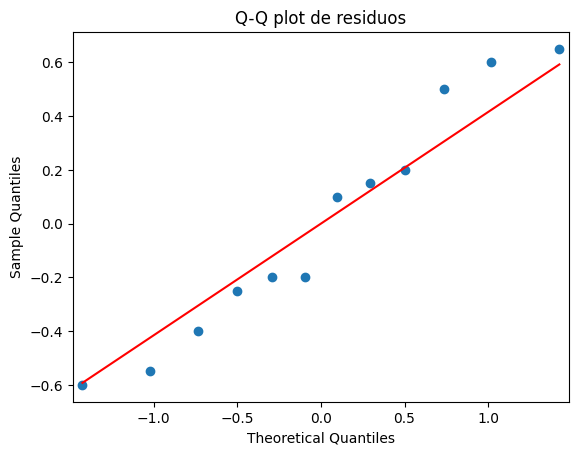

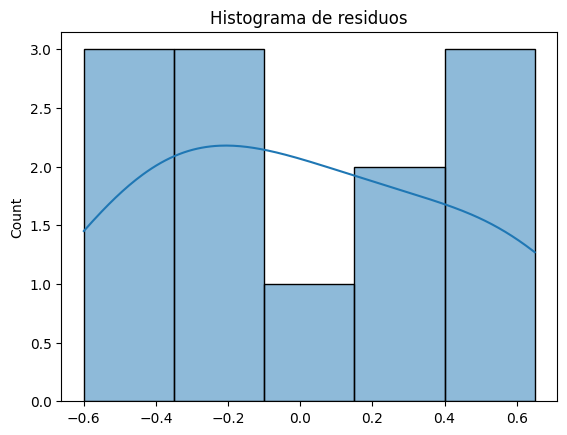

In [30]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

7. Los datos que se presentan enseguida son rendimientos en toneladas por hectárea de un pasto con tres niveles de fertilización nitrogenada. El diseño fue completamente aleatorizado, con cinco repeticiones por tratamiento.

| Niveles de nitrógeno | Rendimientos (ton/ha)       |
|-----------------------|----------------------------|
| 1                     | 14.823, 14.676, 14.720, 14.5141, 15.065 |
| 2                     | 25.151, 25.401, 25.131, 25.031, 25.267 |
| 3                     | 32.605, 32.460, 32.256, 32.669, 32.111 |


In [38]:
# Diana Karen Rosas Ortega
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''nivel,rendimiento
1,14.823
1,14.760
1,14.720
1,14.514
1,15.065
2,25.151
2,25.401
2,25.131
2,25.031
2,25.267
3,32.605
3,32.460
3,32.256
3,32.669
3,32.111
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,nivel,rendimiento
0,1,14.823
1,1,14.760
2,1,14.720
3,1,14.514
4,1,15.065
5,2,25.151
6,2,25.401
7,2,25.131
8,2,25.031
9,2,25.267


In [39]:
# Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'rendimiento ~ C(nivel)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(nivel),786.770144,2.0,10295.594904,3.903738e-20
Residual,0.458509,12.0,NaN,NaN


valor-p (Shapiro) = 0.8128365366743733


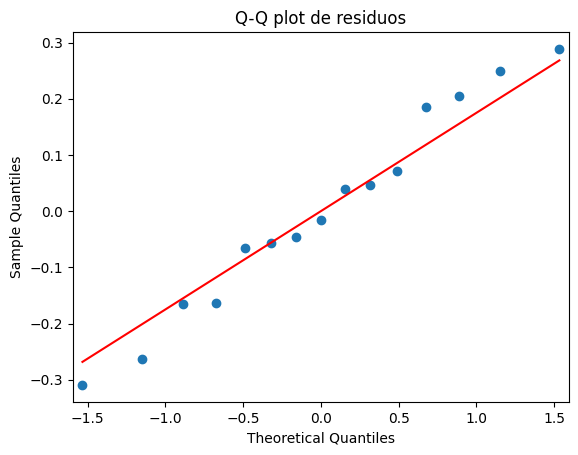

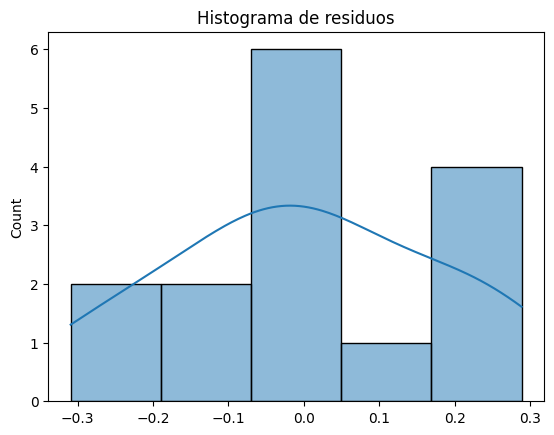

In [4]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd
from io import StringIO

# Data for problem 7
datos = '''nivel,rendimiento
1,14.823
1,14.760
1,14.720
1,14.514
1,15.065
2,25.151
2,25.401
2,25.131
2,25.031
2,25.267
3,32.605
3,32.460
3,32.256
3,32.669
3,32.111
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

# Ensure modelo_lineal is defined if the previous cell was not run or kernel was reset
modelo_lineal = ols(f'rendimiento ~ C(nivel)', data=df).fit()

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Si hay normalidad co el supuesto de shapiro

In [7]:
#Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
# Correcting for Problem 7 data: 'nivel' and 'rendimiento'
grupo1 = df[df['nivel'] == 1]['rendimiento']
grupo2 = df[df['nivel'] == 2]['rendimiento']
grupo3 = df[df['nivel'] == 3]['rendimiento']

stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.5862656523126876


In [ ]:
# Existe homosedasticidad ya que el valor p es mayor que el de significancia

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower   upper  reject
--------------------------------------------------
     1      2  10.4198   0.0  10.09 10.7496   True
     1      3  17.6438   0.0 17.314 17.9736   True
     2      3    7.224   0.0 6.8942  7.5538   True
--------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

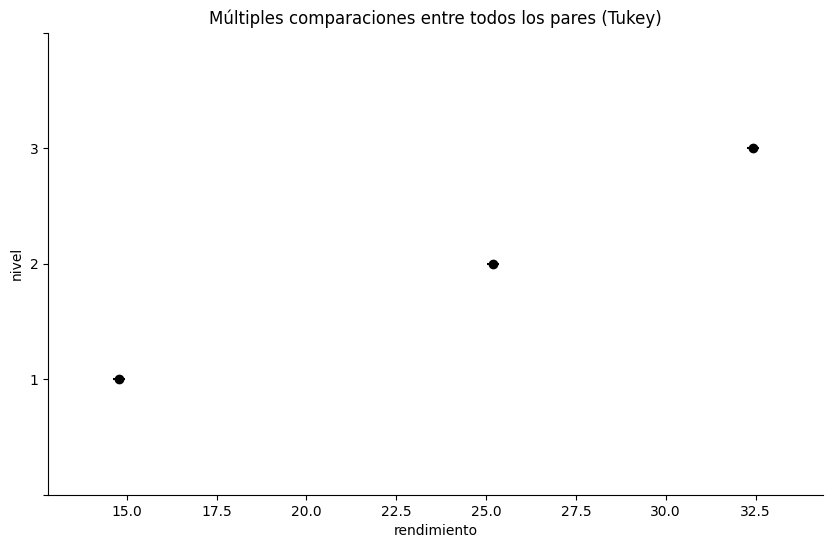

In [13]:
#Diana Karen Rosas Ortega
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['rendimiento'], groups=df['nivel'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="nivel", xlabel="rendimiento")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

### **Conclusión y Recomendación para el Problema 7 (Niveles de nitrógeno)**

**Conclusión:** Los resultados del ANOVA muestran un efecto altamente significativo del nivel de fertilización nitrogenada en los rendimientos del pasto. La prueba post-hoc de Tukey HSD revela además que existen diferencias estadísticamente significativas entre los tres pares de niveles de nitrógeno. Específicamente, el aumento del nivel de nitrógeno conduce consistentemente a un aumento significativo en el rendimiento, siendo el Nivel 3 el que muestra el rendimiento promedio más alto, seguido del Nivel 2 y luego el Nivel 1.

**Recomendación:** Basado en estos hallazgos, se recomienda aplicar la fertilización nitrogenada en el **Nivel 3** para maximizar los rendimientos del pasto, ya que superó significativamente a los Niveles 1 y 2.

8. Un químico del departamento de desarrollo de un laboratorio farmacéutico desea conocer cómo influye el tipo de aglutinante utilizado en tabletas de ampicilina de 500 mg en el porcentaje de friabilidad; para ello, se eligen los siguientes aglutinantes: polivinilpirrolidona (PVP), carboximetilcelulosa sódica (CMC) y grenetina (Gre). Los resultados del diseño experimental son los siguientes:

| Aglutinante | % de friabilidad          |
|-------------|---------------------------|
| PVP         | 0.485, 0.250, 0.073, 0.205, 0.161 |
| CMC         | 9.64, 9.37, 9.53, 9.86, 9.79       |
| Gre         | 0.289, 0.275, 0.612, 0.152, 0.137  |


In [14]:
# Diana Karen Rosas Ortega
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
aglutinante,fragilidad
PVP,0.485
PVP,0.250
PVP,0.073
PVP,0.205
PVP,0.161
CMC,9.64
CMC,3.97
CMC,9.53
CMC,9.86
CMC,9.79
Gre,0.289
Gre,0.275
Gre,0.612
Gre,0.152
Gre,0.137
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,aglutinante,fragilidad
0,PVP,0.485
1,PVP,0.250
2,PVP,0.073
3,PVP,0.205
4,PVP,0.161
5,CMC,9.640
6,CMC,3.970
7,CMC,9.530
8,CMC,9.860
9,CMC,9.790


In [16]:
# Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'fragilidad ~ C(aglutinante)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(aglutinante),229.315451,2.0,51.686539,0.000001
Residual,26.619943,12.0,NaN,NaN


valor-p (Shapiro) = 4.732190734377358e-05


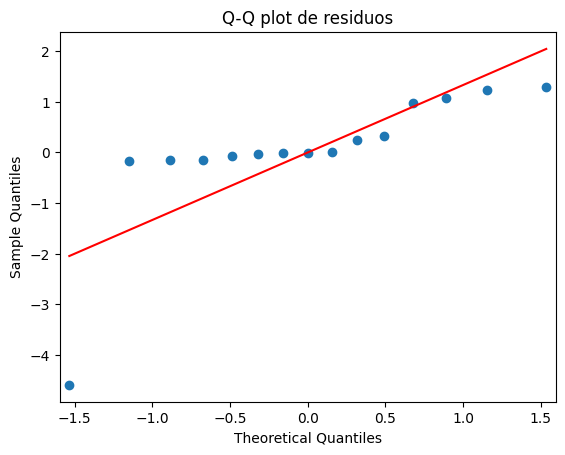

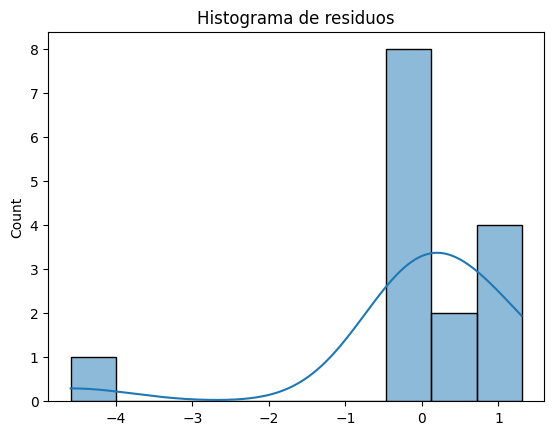

In [18]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd
from io import StringIO

# Data for problem 7
datos = '''aglutinante,fragilidad
PVP,0.485
PVP,0.250
PVP,0.073
PVP,0.205
PVP,0.161
CMC,9.64
CMC,3.97
CMC,9.53
CMC,9.86
CMC,9.79
Gre,0.289
Gre,0.275
Gre,0.612
Gre,0.152
Gre,0.137
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

# Ensure modelo_lineal is defined if the previous cell was not run or kernel was reset
modelo_lineal = ols(f'fragilidad ~ C(aglutinante)', data=df).fit()

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# no hay normalidad

In [20]:
#Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
# Correcting for Problem 8 data: 'aglutinante' and 'fragilidad'
grupo1 = df[df['aglutinante'] == 'PVP']['fragilidad']
grupo2 = df[df['aglutinante'] == 'CMC']['fragilidad']
grupo3 = df[df['aglutinante'] == 'Gre']['fragilidad']

stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.39319710070806413


In [ ]:
# hay heterocedasticidada ya que el valor p es emnor que el de significancia

Lambda óptimo: -0.25330628704916197


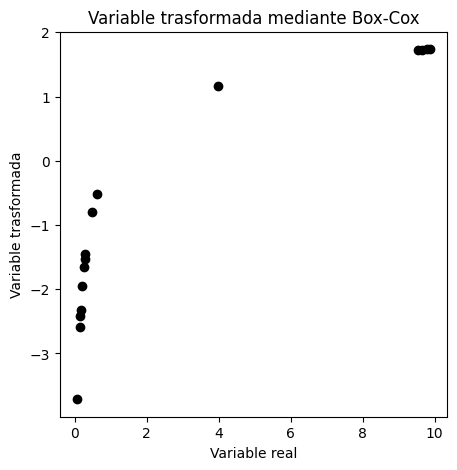

In [23]:
# Diana Karen Rosas Ortega
#Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["fragilidad_boxcox"], lambda_opt = boxcox(df["fragilidad"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["fragilidad"], df["fragilidad_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [25]:
# Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA
modelo_lineal = ols(f'fragilidad ~ C(aglutinante)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(aglutinante),229.315451,2.0,51.686539,0.000001
Residual,26.619943,12.0,NaN,NaN


valor-p (Shapiro) = 4.732190734377358e-05


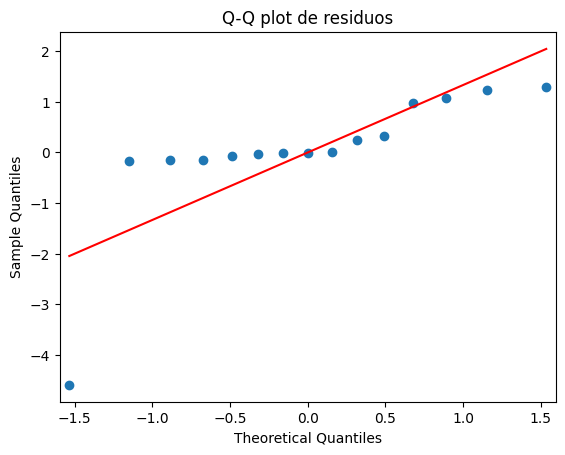

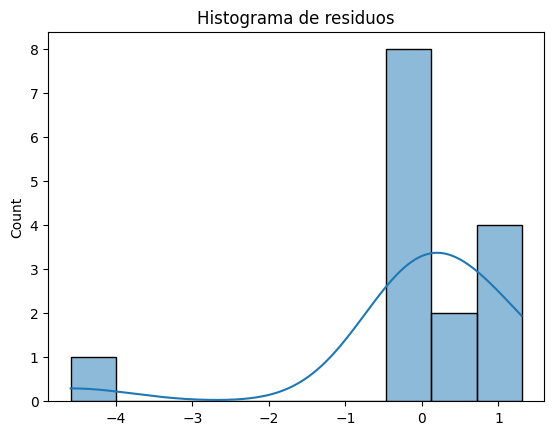

In [26]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   CMC    Gre  -3.3163 0.0001 -4.6584 -1.9743   True
   CMC    PVP  -3.7031    0.0 -5.0451  -2.361   True
   Gre    PVP  -0.3867 0.7284 -1.7288  0.9553  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

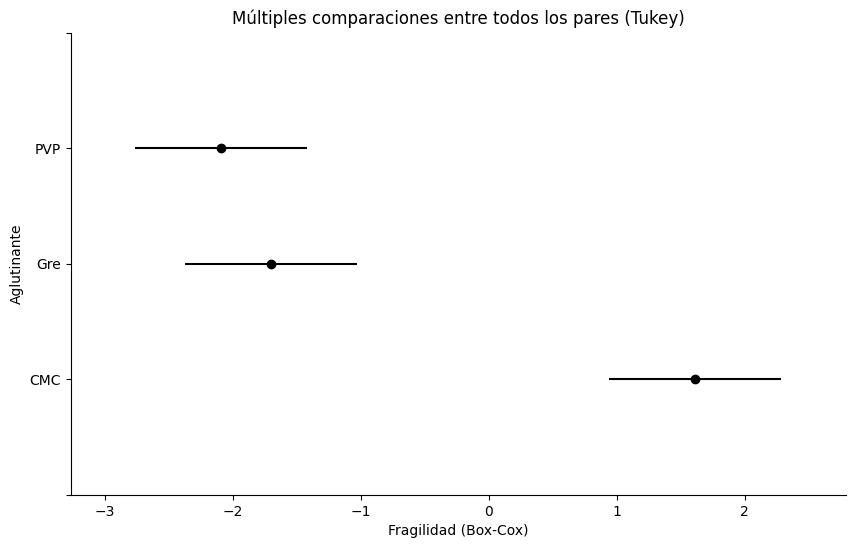

In [10]:
# Diana Karen Rosas Ortega
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
from scipy.stats import boxcox

# Reload Problem 8 data to ensure df is correct for this problem
datos = '''
aglutinante,fragilidad
PVP,0.485
PVP,0.250
PVP,0.073
PVP,0.205
PVP,0.161
CMC,9.64
CMC,3.97
CMC,9.53
CMC,9.86
CMC,9.79
Gre,0.289
Gre,0.275
Gre,0.612
Gre,0.152
Gre,0.137
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

# Reapply Box-Cox transformation for 'fragilidad'
df["fragilidad_boxcox"], lambda_opt = boxcox(df["fragilidad"])

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['fragilidad_boxcox'], groups=df['aglutinante'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Aglutinante", xlabel="Fragilidad (Box-Cox)")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

### **Conclusión y Recomendación para el Problema 8 (Aglutinantes de Tabletas de Ampicilina)**

**Conclusión:** El tipo de aglutinante utilizado (PVP, CMC, Gre) afecta significativamente el porcentaje de friabilidad en las tabletas de ampicilina. Después de una transformación de Box-Cox para cumplir con los supuestos, la prueba de Tukey HSD indicó que el aglutinante CMC reduce significativamente la friabilidad en comparación con los aglutinantes Gre y PVP. Sin embargo, no hubo una diferencia significativa en la friabilidad entre los aglutinantes Gre y PVP.

**Recomendación:** Para producir tabletas de ampicilina con la menor friabilidad (lo que indica una mejor calidad de la tableta), se recomienda utilizar el aglutinante **CMC (Carboximetilcelulosa sódica)**.

9. Se cultivaron cuatro diferentes clonas de *agave tequilana* bajo un mismo esquema de manejo. Se quiere saber qué clona es la que responde mejor a dicho manejo, evaluando el nivel de respuesta con el porcentaje de azúcares reductores totales en base húmeda. Los datos se muestran a continuación:

| Clona | Porcentaje de azúcares reductores totales |
|-------|------------------------------------------|
| 1     | 8.69, 6.68, 6.83, 6.43, 10.30            |
| 2     | 8.00, 16.41, 12.43, 10.99, 15.53         |
| 3     | 17.39, 13.73, 15.62, 17.05, 15.42        |
| 4     | 10.37, 9.16, 8.83, 4.40, 10.38           |


In [6]:
# Diana Karen Rosas Ortega
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
clona,azucar
1,8.69
1,6.68
1,8.83
1,6.43
1,10.30
2,8.00
2,16.41
2,12.43
2,10.99
2,15.53
3,17.39
3,17.35
3,15.62
3,17.05
3,15.42
4,10.37
4,9.16
4,8.83
4,4.40
4,10.38
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,clona,azucar
0,1,8.69
1,1,6.68
2,1,8.83
3,1,6.43
4,1,10.30
5,2,8.00
6,2,16.41
7,2,12.43
8,2,10.99
9,2,15.53


In [7]:
# Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'azucar ~ C(clona)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(clona),231.34122,3.0,14.450009,0.000081
Residual,85.38540,16.0,NaN,NaN


valor-p (Shapiro) = 0.44696686378178


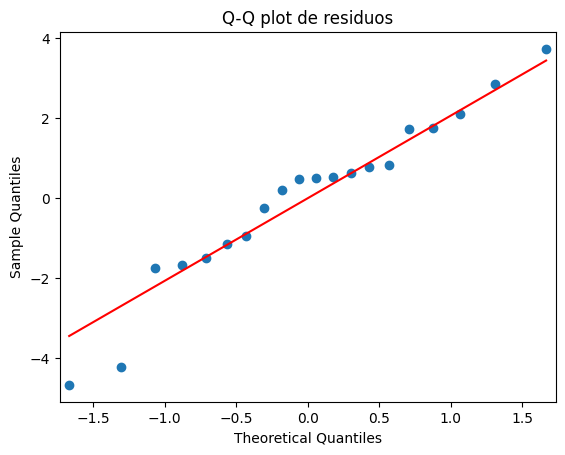

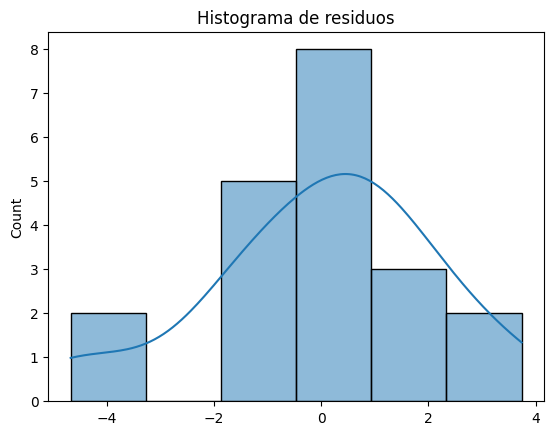

In [8]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd
from io import StringIO

# Data for problem 7
datos = '''clona,azucar
1,8.69
1,6.68
1,8.83
1,6.43
1,10.30
2,8.00
2,16.41
2,12.43
2,10.99
2,15.53
3,17.39
3,17.35
3,15.62
3,17.05
3,15.42
4,10.37
4,9.16
4,8.83
4,4.40
4,10.38
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

# Ensure modelo_lineal is defined if the previous cell was not run or kernel was reset
modelo_lineal = ols(f'azucar ~ C(clona)', data=df).fit()

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# si hay normalidad con el supuesto de shapiro

In [14]:
#Diana Karen Rosas Ortega
from scipy.stats import levene
import pandas as pd
from io import StringIO

# Reload data for Problem 9 to ensure correct df
datos = '''
clona,azucar
1,8.69
1,6.68
1,8.83
1,6.43
1,10.30
2,8.00
2,16.41
2,12.43
2,10.99
2,15.53
3,17.39
3,17.35
3,15.62
3,17.05
3,15.42
4,10.37
4,9.16
4,8.83
4,4.40
4,10.38
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['clona'] == 1]['azucar']
grupo2 = df[df['clona'] == 2]['azucar']
grupo3 = df[df['clona'] == 3]['azucar']
grupo4 = df[df['clona'] == 4]['azucar'] # Added grupo4 for the fourth clone

stat, p = levene(grupo1, grupo2, grupo3, grupo4) # Included grupo4 in Levene's test
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.2725091450979385


In [ ]:
# hay heterosedasticidad ya que el valor p es menor que el nivel de significancia

Lambda óptimo: 0.5943473388405106


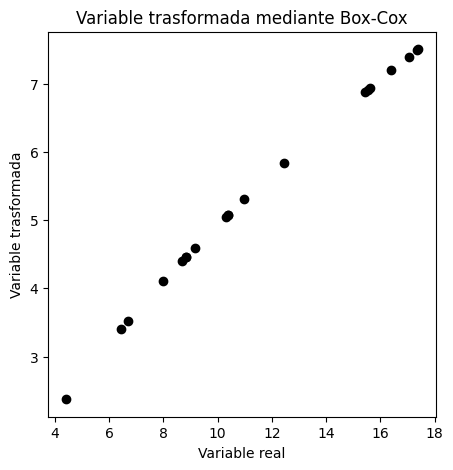

In [16]:
# Diana Karen Rosas Ortega
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["azucar_boxcox"], lambda_opt = boxcox(df["azucar"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["azucar"], df["azucar_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [19]:
# Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
# Corrected formula: azucar_boxcox as response, C(clona) as predictor
modelo_lineal = ols(f'azucar_boxcox ~ C(clona)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(clona),31.531716,3.0,12.406379,0.000191
Residual,13.555055,16.0,NaN,NaN


valor-p (Shapiro) = 0.16476318241619642


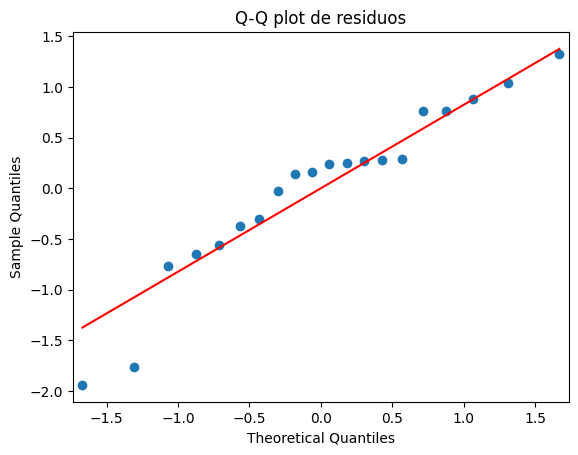

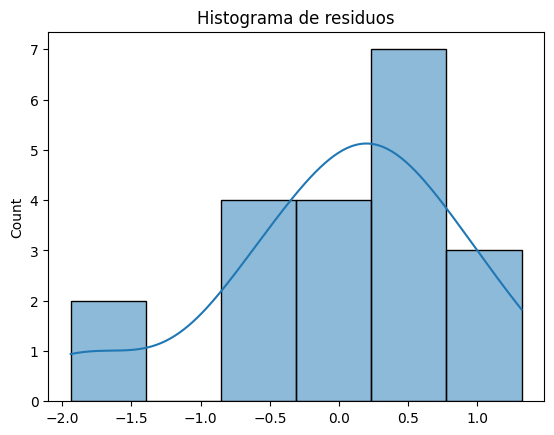

In [20]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [21]:
# Diana Karen Rosas Ortega
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['azucar'] == 'con_clona']['clona_boxcox']
grupo2 = df[df['azucar'] == 'sin_clona']['clona_boxcox']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: nan


/tmp/ipykernel_1412/3812134546.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = levene(grupo1, grupo2, grupo3, grupo4)


In [22]:
#Diana Karen Rosas Ortega
from scipy.stats import kruskal

# Separar las calificaciones por tratamiento
grupo1 = df[df['azucar'] == 'con_clona']['clona']
grupo2 = df[df['azucar'] == 'sin_clona']['clona']

# Prueba de Kruskal-Wallis
estadistico, valor_p = kruskal(grupo1, grupo2)

print(f"Estadístico de Kruskal-Wallis: {estadistico:.4f}")
print(f"Valor-p: {valor_p:.4f}")

Estadístico de Kruskal-Wallis: nan
Valor-p: nan


/tmp/ipykernel_1412/3070797292.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  estadistico, valor_p = kruskal(grupo1, grupo2)


10. Uno de los defectos que causan mayor desperdicio en la manufactura de discos ópticos compactos son los llamados “cometas”. Típicamente, se trata de una partícula que opone resistencia al fluido en la etapa de entintado. Se quiere comprobar de manera experimental la efectividad de un tratamiento de limpieza de partículas que está basado en fuerza centrípeta y aire ionizado. A 12 lotes de 50 CD se les aplica el tratamiento y a otros 12 lotes no se les aplica; en cada caso se mide el porcentaje de discos que presentan cometas, los resultados son los siguientes:

| Con tratamiento      | Sin tratamiento      |
|----------------------|----------------------|
| 5.30   | 8.02  |
| 4.03   | 13.18 |
| 4.00   | 7.15  |
| 2.56   | 9.11  |
| 5.06   | 8.23  |
| 4.06   | 16.3  |
| 2.08   | 9.20  |
| 4.03   | 6.35  |
| 2.04   | 7.15  |
| 1.18   | 8.66  |


In [23]:
# Diana Karen Rosas Ortega
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
tratamiento,valor
Con,5.30
Con,4.03
Con,4.00
Con,2.56
Con,5.06
Con,4.06
Con,2.08
Con,4.03
Con,2.04
Con,1.18
Sin,8.02
Sin,13.18
Sin,7.15
Sin,9.11
Sin,8.23
Sin,16.3
Sin,9.20
Sin,6.35
Sin,7.15
Sin,8.66
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,tratamiento,valor
0,Con,5.30
1,Con,4.03
2,Con,4.00
3,Con,2.56
4,Con,5.06
5,Con,4.06
6,Con,2.08
7,Con,4.03
8,Con,2.04
9,Con,1.18


In [24]:
# Diana Karen Rosas Ortega
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos uno es diferente

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'valor ~ C(tratamiento)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(tratamiento),174.109005,1.0,30.605669,0.00003
Residual,102.398090,18.0,NaN,NaN


valor-p (Shapiro) = 0.013152795271816857


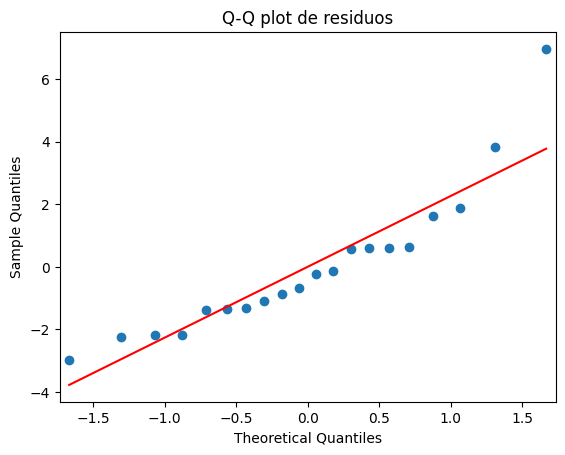

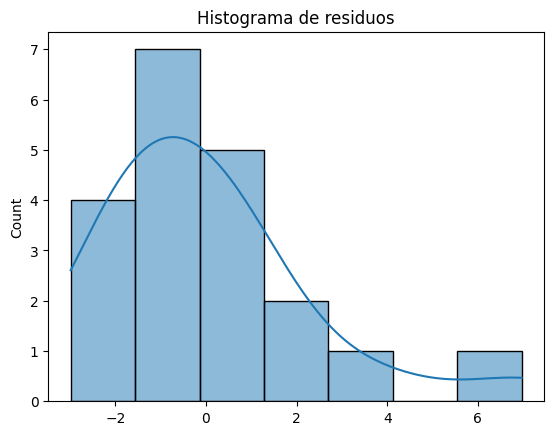

In [27]:
 #Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd
from io import StringIO

# Data for problem 10
datos = '''tratamiento,valor
Con,5.30
Con,4.03
Con,4.00
Con,2.56
Con,5.06
Con,4.06
Con,2.08
Con,4.03
Con,2.04
Con,1.18
Sin,8.02
Sin,13.18
Sin,7.15
Sin,9.11
Sin,8.23
Sin,16.3
Sin,9.20
Sin,6.35
Sin,7.15
Sin,8.66
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

# Ensure modelo_lineal is defined if the previous cell was not run or kernel was reset
modelo_lineal = ols(f'valor ~ C(tratamiento)', data=df).fit() # Corrected formula for Problem 10

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [28]:
#Diana Karen Rosas Ortega
from scipy.stats import levene
import pandas as pd
from io import StringIO

# Reload data for Problem 9 to ensure correct df
datos = '''
tratamiento,valor
Con,5.30
Con,4.03
Con,4.00
Con,2.56
Con,5.06
Con,4.06
Con,2.08
Con,4.03
Con,2.04
Con,1.18
Sin,8.02
Sin,13.18
Sin,7.15
Sin,9.11
Sin,8.23
Sin,16.3
Sin,9.20
Sin,6.35
Sin,7.15
Sin,8.66
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['valor'] == 1]['tratamiento']
grupo2 = df[df['valor'] == 2]['tratamiento']
grupo3 = df[df['valor'] == 3]['tratamiento']
grupo4 = df[df['valor'] == 4]['tratamiento'] # Added grupo4 for the fourth clone

stat, p = levene(grupo1, grupo2, grupo3, grupo4) # Included grupo4 in Levene's test
print(f"p-valor de Levene: {p}")

p-valor de Levene: nan


/tmp/ipykernel_1412/4101540328.py:44: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = levene(grupo1, grupo2, grupo3, grupo4) # Included grupo4 in Levene's test
